# Netflix Data Exploration

## 1. 데이터 탐색

### 1.1 문제 정의
다양한 장르에따라 많은 분류를하여 시각화하여 보여준다.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # Alignments 

import seaborn as sns # theme & dataset
print(f"Matplotlib Version : {mpl.__version__}")
print(f"Seaborn Version : {sns.__version__}")

# for visualization samples
import pandas as pd

data = pd.read_csv("~/aiffel/Hackathon_01/data/netflix_titles.csv")
data.head()

Matplotlib Version : 3.4.3
Seaborn Version : 0.11.2


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


* Show_id: Unique ID for every Movie / Tv Show
* Type: Identifier - A Movie or TV Show
* Title: Title of the Movie / Tv Show
* Director: Director of the Movie
* Cast: Actors involved in the movie/show
* Country: Country where the movie/show was produced
* Date_added: Date it was added on Netflix
* Release_year: Actual Release year of the movie/show
* Rating: TV Rating of the movie/show
* Duration: Total Duration - in minutes or number of seasons
* Listed_in: Genre
* Description: The summary description

In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [3]:
data.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

## 1.2 사용하지 않는 col제거

show_id, director, date_added, description 제거

In [4]:
data_titles = data[['type', 'title', 'cast', 'country', 'release_year', 'rating', 'duration', 'listed_in']]
data_titles.head(10)

,type,title,cast,country,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,NaN,United States,2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,NaN,NaN,2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
5,TV Show,Midnight Mass,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
6,Movie,My Little Pony: A New Generation,"Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021,PG,91 min,Children & Family Movies
7,Movie,Sankofa,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
8,TV Show,The Great British Baking Show,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021,TV-14,9 Seasons,"British TV Shows, Reality TV"
9,Movie,The Starling,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,104 min,"Comedies, Dramas"


<AxesSubplot:>

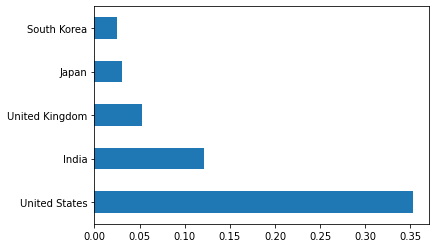

In [5]:
data_titles['country'].value_counts(normalize=True)[:5].plot(kind='barh')

## movie중 상위5개 보여줌

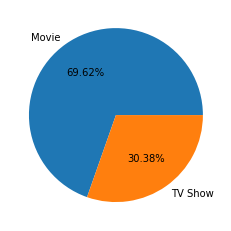

In [6]:
color=['black','red']
type_value_count = data_titles['type'].value_counts(normalize=True)*100
content_types = data_titles['type'].unique()
plt.pie(type_value_count,labels=content_types,autopct='%.2f%%')
plt.savefig('contribution.jpg')
plt.show()

In [7]:
us = data_titles[data_titles['country']=='United States']

In [8]:
us_listed = us["listed_in"].value_counts()
us_listed 

Documentaries                                         249
Stand-Up Comedy                                       209
Children & Family Movies, Comedies                     90
Dramas                                                 88
Comedies                                               84
                                                     ... 
International TV Shows, Reality TV, TV Comedies         1
Kids' TV, TV Action & Adventure, TV Dramas              1
Anime Series, Crime TV Shows                            1
Anime Features, Music & Musicals, Sci-Fi & Fantasy      1
Cult Movies, Dramas, Thrillers                          1
Name: listed_in, Length: 310, dtype: int64

In [9]:
# data_titles = data_titles.iloc[[95, 96]]
print(data_titles)

         type                  title  \
0       Movie   Dick Johnson Is Dead   
1     TV Show          Blood & Water   
2     TV Show              Ganglands   
3     TV Show  Jailbirds New Orleans   
4     TV Show           Kota Factory   
...       ...                    ...   
8802    Movie                 Zodiac   
8803  TV Show            Zombie Dumb   
8804    Movie             Zombieland   
8805    Movie                   Zoom   
8806    Movie                 Zubaan   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2     Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                   NaN            NaN   
4     Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   
...                                                 ...            ...   
8

In [10]:
# 장르 
data_movie = data_titles.loc[data_titles.type == 'Movie']
data_tv = data_titles.loc[data_titles.type == 'TV Show']

In [11]:
num_data_titles = len(data_titles)
num_data_movie = len(data_movie)
num_data_tv = len(data_tv)

print(num_data_titles)
print(num_data_movie)
print(num_data_tv)

8807
6131
2676


In [12]:
# 결측치 확인
print('data_titles :')
print(data_titles.isnull().sum())

print('\ndata_movie :')
print(data_movie.isnull().sum())

print('\ndata_tv :')
print(data_tv.isnull().sum())

data_titles :
type              0
title             0
cast            825
country         831
release_year      0
rating            4
duration          3
listed_in         0
dtype: int64

data_movie :
type              0
title             0
cast            475
country         440
release_year      0
rating            2
duration          3
listed_in         0
dtype: int64

data_tv :
type              0
title             0
cast            350
country         391
release_year      0
rating            2
duration          0
listed_in         0
dtype: int64


In [13]:
def split_multi_data_in_col(df, name_col, str_split):
    num_df = len(df)
    result_df = df.drop(index=df.index)
    for idx in range(num_df):
        row = df.iloc[idx]
        keys = row.index
        vals = [[val]for val in row.values]
        dic_row = dict(zip(keys, vals))

        val_col = row[name_col]
        if type(row[name_col]) != str:
            df_row = pd.DataFrame(dic_row)
            result_df = pd.concat([result_df, df_row])
        else:
            val_col = row[name_col].split(str_split)
            for val in val_col:
                dic_row[name_col] = val
                df_row = pd.DataFrame(dic_row)
                result_df = pd.concat([result_df, df_row])
    return result_df.reset_index().drop('index', axis=1)

In [14]:
# 'listed_in'
data_titles_genre_split = split_multi_data_in_col(data_titles, 'listed_in', ', ')

In [15]:
print(data_titles_genre_split)
print(len(data_titles_genre_split))

          type                 title  \
0        Movie  Dick Johnson Is Dead   
1      TV Show         Blood & Water   
2      TV Show         Blood & Water   
3      TV Show         Blood & Water   
4      TV Show             Ganglands   
...        ...                   ...   
19318    Movie                  Zoom   
19319    Movie                  Zoom   
19320    Movie                Zubaan   
19321    Movie                Zubaan   
19322    Movie                Zubaan   

                                                    cast        country  \
0                                                    NaN  United States   
1      Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2      Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
3      Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
4      Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
...                                                  ...            .

In [16]:
# 'country'
data_titles_country_split = split_multi_data_in_col(data_titles_genre_split, 'country', ', ')

In [17]:
print(data_titles_country_split)
print(len(data_titles_country_split))

          type                 title  \
0        Movie  Dick Johnson Is Dead   
1      TV Show         Blood & Water   
2      TV Show         Blood & Water   
3      TV Show         Blood & Water   
4      TV Show             Ganglands   
...        ...                   ...   
23749    Movie                  Zoom   
23750    Movie                  Zoom   
23751    Movie                Zubaan   
23752    Movie                Zubaan   
23753    Movie                Zubaan   

                                                    cast        country  \
0                                                    NaN  United States   
1      Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2      Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
3      Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
4      Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
...                                                  ...            .

In [18]:
genre_unique = data_titles_genre_split['listed_in'].unique()
print(genre_unique)

['Documentaries' 'International TV Shows' 'TV Dramas' 'TV Mysteries'
 'Crime TV Shows' 'TV Action & Adventure' 'Docuseries' 'Reality TV'
 'Romantic TV Shows' 'TV Comedies' 'TV Horror' 'Children & Family Movies'
 'Dramas' 'Independent Movies' 'International Movies' 'British TV Shows'
 'Comedies' 'Spanish-Language TV Shows' 'Thrillers' 'Romantic Movies'
 'Music & Musicals' 'Horror Movies' 'Sci-Fi & Fantasy' 'TV Thrillers'
 "Kids' TV" 'Action & Adventure' 'TV Sci-Fi & Fantasy' 'Classic Movies'
 'Anime Features' 'Sports Movies' 'Anime Series' 'Korean TV Shows'
 'Science & Nature TV' 'Teen TV Shows' 'Cult Movies' 'TV Shows'
 'Faith & Spirituality' 'LGBTQ Movies' 'Stand-Up Comedy' 'Movies'
 'Stand-Up Comedy & Talk Shows' 'Classic & Cult TV']


In [19]:
check_na = data_titles_country_split['country'].notna()
data_country = data_titles_country_split.loc[check_na]

In [20]:
country = data_country['country'].unique()
print(country)

['United States' 'South Africa' 'India' 'Ghana' 'Burkina Faso'
 'United Kingdom' 'Germany' 'Ethiopia' 'Czech Republic' 'Mexico' 'Turkey'
 'Australia' 'France' 'Finland' 'China' 'Canada' 'Japan' 'Nigeria' 'Spain'
 'Belgium' 'South Korea' 'Singapore' 'Italy' 'Romania' 'Argentina'
 'Venezuela' 'Hong Kong' 'Russia' '' 'Ireland' 'Nepal' 'New Zealand'
 'Brazil' 'Greece' 'Jordan' 'Colombia' 'Switzerland' 'Israel' 'Taiwan'
 'Bulgaria' 'Algeria' 'Poland' 'Saudi Arabia' 'Thailand' 'Indonesia'
 'Egypt' 'Denmark' 'Kuwait' 'Netherlands' 'Malaysia' 'Vietnam' 'Hungary'
 'Sweden' 'Lebanon' 'Syria' 'Philippines' 'Iceland' 'United Arab Emirates'
 'Norway' 'Qatar' 'Mauritius' 'Austria' 'Cameroon' 'Palestine' 'Uruguay'
 'United Kingdom,' 'Kenya' 'Chile' 'Luxembourg' 'Cambodia' 'Bangladesh'
 'Portugal' 'Cayman Islands' 'Senegal' 'Serbia' 'Malta' 'Namibia' 'Angola'
 'Peru' 'Mozambique' 'Cambodia,' 'Belarus' 'Zimbabwe' 'Puerto Rico'
 'Pakistan' 'Cyprus' 'Guatemala' 'Iraq' 'Malawi' 'Paraguay' 'Croatia'
 'Iran

In [21]:
group_contry = data_country['listed_in'].groupby(data_country['country'])
a = group_contry.unique()
print(a['Afghanistan'])
print(type(a))
print(a.index)
print(a.values)

['Documentaries' 'International Movies']
<class 'pandas.core.series.Series'>
Index(['', 'Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina',
       'Armenia', 'Australia', 'Austria', 'Azerbaijan',
       ...
       'United Kingdom', 'United Kingdom,', 'United States', 'United States,',
       'Uruguay', 'Vatican City', 'Venezuela', 'Vietnam', 'West Germany',
       'Zimbabwe'],
      dtype='object', name='country', length=127)
[array(['International TV Shows', 'TV Dramas', 'Dramas',
        'Independent Movies', 'International Movies'], dtype=object)
 array(['Documentaries', 'International Movies'], dtype=object)
 array(['Dramas', 'International Movies'], dtype=object)
 array(['Dramas', 'Independent Movies', 'International Movies',
        'Classic Movies'], dtype=object)
 array(['Action & Adventure', 'International Movies'], dtype=object)
 array(['Dramas', 'International Movies', 'Thrillers', 'Crime TV Shows',
        'International TV Shows', 'Spanish-Language TV Shows', 'Come

In [22]:
a = group_contry.count()
print(a)

country
                 5
Afghanistan      2
Albania          2
Algeria          8
Angola           2
                ..
Vatican City     3
Venezuela        8
Vietnam         20
West Germany    11
Zimbabwe         7
Name: listed_in, Length: 127, dtype: int64


In [23]:
a = group_contry.value_counts()
print(a)

country       listed_in             
              Dramas                    1
              Independent Movies        1
              International Movies      1
              International TV Shows    1
              TV Dramas                 1
                                       ..
West Germany  Thrillers                 1
Zimbabwe      International Movies      3
              Documentaries             2
              Comedies                  1
              Romantic Movies           1
Name: listed_in, Length: 1422, dtype: int64


In [24]:
print(a['Afghanistan'])
print('\n')
print(a['Afghanistan']['Documentaries'])

listed_in
Documentaries           1
International Movies    1
Name: listed_in, dtype: int64


1


In [25]:
# 국가 추출
data_country = data_titles['country'].dropna()
data_country = data_country.unique()
print('국가 개수 : ', len(data_country))

# 국가별 장르
data_titles.groupby(['country'])

국가 개수 :  748


In [26]:
data_country

array(['United States', 'South Africa', 'India',
       'United States, Ghana, Burkina Faso, United Kingdom, Germany, Ethiopia',
       'United Kingdom', 'Germany, Czech Republic', 'Mexico', 'Turkey',
       'Australia', 'United States, India, France', 'Finland',
       'China, Canada, United States',
       'South Africa, United States, Japan', 'Nigeria', 'Japan',
       'Spain, United States', 'France', 'Belgium',
       'United Kingdom, United States', 'United States, United Kingdom',
       'France, United States', 'South Korea', 'Spain',
       'United States, Singapore', 'United Kingdom, Australia, France',
       'United Kingdom, Australia, France, United States',
       'United States, Canada', 'Germany, United States',
       'South Africa, United States', 'United States, Mexico',
       'United States, Italy, France, Japan',
       'United States, Italy, Romania, United Kingdom',
       'Australia, United States', 'Argentina, Venezuela',
       'United States, United Kingdom,

#   연도별 장르 분포
2021~ 2012  
2011~ 2001

가장 많이 개봉한 장르  
가장 많이 개봉한 국가  

연도별로 장르데이터 뽑기 아직 못함.

In [27]:
# 년도별 개봉 영화 개수
data_titles['release_year'].value_counts()

2018    1147
2017    1032
2019    1030
2020     953
2016     902
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: release_year, Length: 74, dtype: int64

In [28]:
# 영화가 개봉된 년도 개수
years = data_titles['release_year'].unique()
print(len(years))
print(np.sort(years))

74
[1925 1942 1943 1944 1945 1946 1947 1954 1955 1956 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021]


<AxesSubplot:>

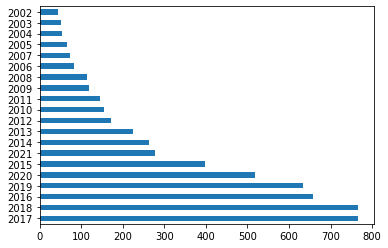

In [29]:
data_titles[data_titles["type"]=="Movie"]["release_year"].value_counts()[:20].plot(kind='barh')

<AxesSubplot:>

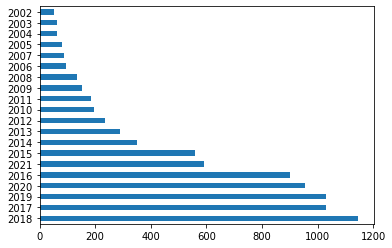

In [30]:
# 년도별 개봉영화 개수 상위 20개 차트
data_titles['release_year'].value_counts()[:20].plot(kind='barh')

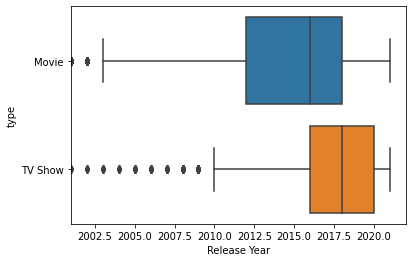

In [32]:
# movie와 tv show 각각 개봉년도의 이상치와 중간값등 비교
sns.boxplot(data = data_titles, x ='release_year' ,y='type')
plt.xlabel('Release Year')
plt.xlim(2001,2022)
plt.savefig('Trend_over_year.jpg')
plt.show()

Text(0.5, 1.0, 'Frequency of Movies which were released in different years and are available on Netflix')

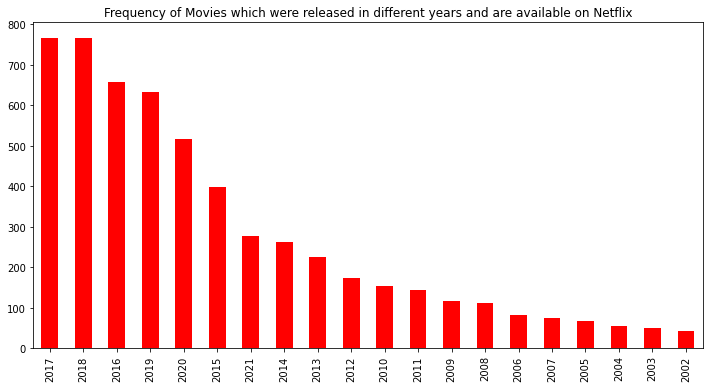

In [33]:
'''plt.figure(figsize=(12,6))
data_titles[data_titles["type"]=="Movie"]["release_year"].value_counts()[:20].plot(kind="bar",color="Red")
plt.title("Frequency of Movies which were released in different years and are available on Netflix")'''

Text(0.5, 1.0, 'Top 10 Genres of Movies')

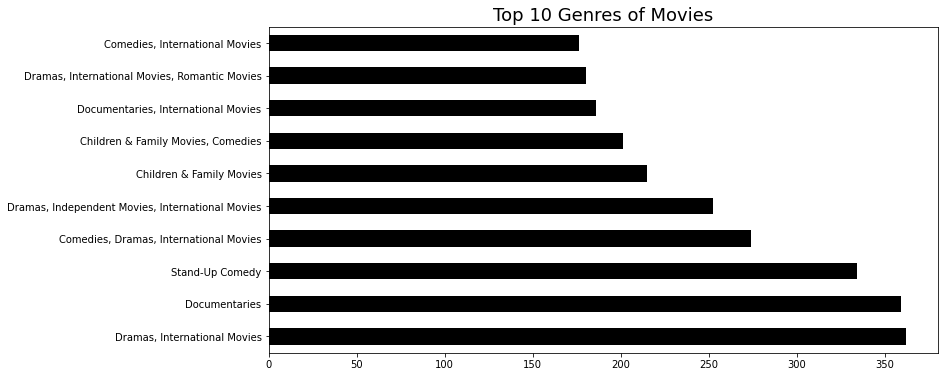

In [34]:
'''plt.figure(figsize=(12,6))
data_titles[data_titles["type"]=="Movie"]["listed_in"].value_counts()[:10].plot(kind="barh",color="black")
plt.title("Top 10 Genres of Movies",size=18)'''

In [ ]:
print(len(data_titles_country_split))

In [36]:
check_na = data_titles_country_split['country'].notna()
data_country = data_titles_country_split.loc[check_na]
country = data_country['country'].unique()
print(country)

['United States' 'South Africa' 'India' 'Ghana' 'Burkina Faso'
 'United Kingdom' 'Germany' 'Ethiopia' 'Czech Republic' 'Mexico' 'Turkey'
 'Australia' 'France' 'Finland' 'China' 'Canada' 'Japan' 'Nigeria' 'Spain'
 'Belgium' 'South Korea' 'Singapore' 'Italy' 'Romania' 'Argentina'
 'Venezuela' 'Hong Kong' 'Russia' '' 'Ireland' 'Nepal' 'New Zealand'
 'Brazil' 'Greece' 'Jordan' 'Colombia' 'Switzerland' 'Israel' 'Taiwan'
 'Bulgaria' 'Algeria' 'Poland' 'Saudi Arabia' 'Thailand' 'Indonesia'
 'Egypt' 'Denmark' 'Kuwait' 'Netherlands' 'Malaysia' 'Vietnam' 'Hungary'
 'Sweden' 'Lebanon' 'Syria' 'Philippines' 'Iceland' 'United Arab Emirates'
 'Norway' 'Qatar' 'Mauritius' 'Austria' 'Cameroon' 'Palestine' 'Uruguay'
 'United Kingdom,' 'Kenya' 'Chile' 'Luxembourg' 'Cambodia' 'Bangladesh'
 'Portugal' 'Cayman Islands' 'Senegal' 'Serbia' 'Malta' 'Namibia' 'Angola'
 'Peru' 'Mozambique' 'Cambodia,' 'Belarus' 'Zimbabwe' 'Puerto Rico'
 'Pakistan' 'Cyprus' 'Guatemala' 'Iraq' 'Malawi' 'Paraguay' 'Croatia'
 'Iran

In [37]:
years = data_titles_country_split['listed_in'].notna()
data_listed_in = data_titles_country_split.loc[years]

In [38]:
# listed_in 전체 개수와 종류
listed_in = data_listed_in['listed_in'].unique()
print(len(listed_in))
print(listed_in)

42
['Documentaries' 'International TV Shows' 'TV Dramas' 'TV Mysteries'
 'Crime TV Shows' 'TV Action & Adventure' 'Docuseries' 'Reality TV'
 'Romantic TV Shows' 'TV Comedies' 'TV Horror' 'Children & Family Movies'
 'Dramas' 'Independent Movies' 'International Movies' 'British TV Shows'
 'Comedies' 'Spanish-Language TV Shows' 'Thrillers' 'Romantic Movies'
 'Music & Musicals' 'Horror Movies' 'Sci-Fi & Fantasy' 'TV Thrillers'
 "Kids' TV" 'Action & Adventure' 'TV Sci-Fi & Fantasy' 'Classic Movies'
 'Anime Features' 'Sports Movies' 'Anime Series' 'Korean TV Shows'
 'Science & Nature TV' 'Teen TV Shows' 'Cult Movies' 'TV Shows'
 'Faith & Spirituality' 'LGBTQ Movies' 'Stand-Up Comedy' 'Movies'
 'Stand-Up Comedy & Talk Shows' 'Classic & Cult TV']


시각화는 누적막대

* 데이터 가공/전처리
* 패턴 도출
* 시각화
* 인사이트 도출

# 장르별 영상 등급 분포

장르에 결측치값 4개를 발견하여
어떠한 자료인지 확인 후 상영시간에 있어야 하는 값임을 확인.
그자리를 NR값으로 변환

In [39]:
data_titles.isnull().sum()

type              0
title             0
cast            825
country         831
release_year      0
rating            4
duration          3
listed_in         0
dtype: int64

In [53]:
ratings_ages = {
    'TV-PG': 'Older Kids',
    'TV-MA': 'Adults',
    'TV-Y7-FV': 'Older Kids',
    'TV-Y7': 'Older Kids',
    'TV-14': 'Teens',
    'R': 'Adults',
    'TV-Y': 'Kids',
    'NR': 'Adults',
    'PG-13': 'Teens',
    'TV-G': 'Kids',
    'PG': 'Older Kids',
    'G': 'Kids',
    'UR': 'Adults',
    'NC-17': 'Adults'
}

In [54]:
data_titles["rating"].value_counts()

TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            83
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: rating, dtype: int64

In [41]:
data_titles[data_titles["rating"].isin(["74 min","84 min","66 min"])]

,type,title,cast,country,release_year,rating,duration,listed_in
5541,Movie,Louis C.K. 2017,Louis C.K.,United States,2017,74 min,NaN,Movies
5794,Movie,Louis C.K.: Hilarious,Louis C.K.,United States,2010,84 min,NaN,Movies
5813,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,United States,2015,66 min,NaN,Movies


In [42]:
data_titles["rating"].replace(["74 min","84 min","66 min"], "NR", inplace= True)

/opt/conda/lib/python3.9/site-packages/pandas/core/generic.py:6619: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


In [43]:
data_titles.loc[[5541,5794,5813],"duration"]=["74 min","84 min","66 min"]

/opt/conda/lib/python3.9/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [52]:
data_titles.loc[[5541,5794,5813]]

,type,title,cast,country,release_year,rating,duration,listed_in,target_ages
5541,Movie,Louis C.K. 2017,Louis C.K.,United States,2017,NR,74 min,Movies,Adults
5794,Movie,Louis C.K.: Hilarious,Louis C.K.,United States,2010,NR,84 min,Movies,Adults
5813,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,United States,2015,NR,66 min,Movies,Adults


In [49]:
data_titles['target_ages'] = data_titles['rating'].replace(ratings_ages)
data_titles['target_ages'].unique()

/tmp/ipykernel_31/340281154.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_titles['target_ages'] = data_titles['rating'].replace(ratings_ages)


array(['Teens', 'Adults', 'Older Kids', 'Kids', nan], dtype=object)

In [50]:
print(data_titles["rating"])

0       PG-13
1       TV-MA
2       TV-MA
3       TV-MA
4       TV-MA
        ...  
8802        R
8803    TV-Y7
8804        R
8805       PG
8806    TV-14
Name: rating, Length: 8807, dtype: object


In [ ]:
import plotly.graph_objects as go
import plotly.express as px

In [ ]:
px.histogram(count_country, x = "Country", color = "type",
            title="Top 20 Countries with the most streaming content").update_xaxes(categoryorder = "total descending", range=(0, 20))